comment ça fonctionne 
-> combine pleins d'arbres de décision
-> processus séquentiel. L'arbre n°1 fait une prédiction. L'arbre n°2 se concentre uniquement sur les erreurs du n°1 pour les corriger. L'arbre n°3 corrige le n°2, et ainsi de suite
-> À la fin, le modèle fait la somme de toutes ces corrections pour une préd finale

-> Il donne des Probabilités (softprob) 
-> Il gère les relations complexes (non linéaire)
-> Il résiste au Bruit -> à optimiser

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, brier_score_loss
from sklearn.utils.class_weight import compute_sample_weight
import config as cfg
import shap
from sklearn.calibration import calibration_curve

# config
sys.path.append(os.getcwd())

try:
    import config as cfg
    path = cfg.FILE_MATCHES_ELO
    df_raw = pd.read_csv(path, sep=";", parse_dates=["MatchDate"], dayfirst=True)
except ImportError:
    print("Config pas trouvée")

# filtrage (voir explication prépa données)
# Big 5
target_divs = ['E0', 'F1', 'D1', 'I1', 'SP1'] 
df = df_raw[df_raw["Division"].isin(target_divs)].copy()

# > 2006
df = df[df['MatchDate'].dt.year >= 2006].sort_values("MatchDate").reset_index(drop=True)

df["Target"] = df["FTResult"].map({'H': 0, 'D': 1, 'A': 2})

# on remet les variables brutes (Moyenne des 5 derniers matchs)
def add_rolling_stats(df, windows=[5]):
    stats_source = [
        "FTHomeGoals", "FTAwayGoals", 
        "HomeShots", "AwayShots", 
        "HomeCorners", "AwayCorners", 
        "HomeFouls", "AwayFouls",
        "HomeYellow", "AwayYellow",
        "HomeRed", "AwayRed",
        "HomeTarget", "AwayTarget",
        "CardsDiff", "GameDominanceIndex", 
        "ShotsDifference", "CornersDifference" 
    ]
        
    stats_source = [c for c in stats_source if c in df.columns]

    new_feats = []
    
    for col in stats_source:
        for w in windows:
            # Stats Domicile (Moyenne des 5 derniers matchs à domicile)
            feat_h = f"H_{col}_Last{w}"
            df[feat_h] = df.groupby("HomeTeam")[col].transform(lambda x: x.shift(1).rolling(window=w).mean())
            new_feats.append(feat_h)
            
            # Stats Extérieur 
            feat_a = f"A_{col}_Last{w}"
            df[feat_a] = df.groupby("AwayTeam")[col].transform(lambda x: x.shift(1).rolling(window=w).mean())
            new_feats.append(feat_a)
            
    return df, new_feats

df, technical_feats = add_rolling_stats(df, windows=[5])

# nettoyage
cols_leak = [
    "FTHome", "FTAway", "FTResult", "HTHome", "HTAway", "HTResult",
    "HomeShots", "AwayShots", "HomeTarget", "AwayTarget",
    "HomeFouls", "AwayFouls", "HomeCorners", "AwayCorners",
    "HomeYellow", "AwayYellow", "HomeRed", "AwayRed",
    "FTHomeGoals", "FTAwayGoals", "CardsDiff", 
    "GameDominanceIndex", "ShotsDifference", "CornersDifference"
]
cols_leak = [c for c in cols_leak if c in df.columns]
df.drop(columns=cols_leak, inplace=True)

# Suppression des lignes incomplètes 
cols_mandatory = technical_feats + ["Target", "OddHome", "OddDraw", "OddAway"]
df_model = df.dropna(subset=cols_mandatory).reset_index(drop=True)

print(f"dataset : {df_model.shape}")
print(f"Matchs : {len(df_model)}")

dataset : (32145, 76)
Matchs : 32145


In [15]:
# V0 : BASELINE MARCHÉ (SANS ML)
print("V0 : PRÉDICTION MARCHÉ (SUIVRE LE FAVORI)")

# On utilise le même découpage temporel pour être comparable
tscv = TimeSeriesSplit(n_splits=5)
market_acc_scores = []

for fold_id, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    # On isole les données de test
    df_test_fold = df_model.iloc[test_idx]
    
    odds_cols = ["OddHome", "OddDraw", "OddAway"]
    market_preds = df_test_fold[odds_cols].idxmin(axis=1).map({
        "OddHome": 0, 
        "OddDraw": 1, 
        "OddAway": 2
    })
    
    acc = accuracy_score(df_test_fold["Target"], market_preds)
    market_acc_scores.append(acc)
    
    # Date de fin du fold pour info
    d_date = df_test_fold["MatchDate"].max().date()
    print(f"Fold {fold_id+1} | Fin: {d_date} | Accuracy Marché: {acc:.2%}")

print(f"ACCURACY MOYENNE MARCHÉ : {np.mean(market_acc_scores):.2%}")
print("C'est le score à battre pour prouver une 'Value'")

V0 : PRÉDICTION MARCHÉ (SUIVRE LE FAVORI)
Fold 1 | Fin: 2013-01-26 | Accuracy Marché: 52.44%
Fold 2 | Fin: 2016-02-03 | Accuracy Marché: 53.24%
Fold 3 | Fin: 2019-02-04 | Accuracy Marché: 55.16%
Fold 4 | Fin: 2022-02-13 | Accuracy Marché: 53.16%
Fold 5 | Fin: 2025-02-26 | Accuracy Marché: 54.13%
ACCURACY MOYENNE MARCHÉ : 53.63%
C'est le score à battre pour prouver une 'Value'


V1 : XGBOOST AVEC COTES (BENCHMARK)
Training sur 38 variables (dont Cotes)...
Fold 1 | Modèle: 50.46% vs Marché: 52.44% (Delta: -1.98%)
Fold 2 | Modèle: 52.31% vs Marché: 53.24% (Delta: -0.93%)
Fold 3 | Modèle: 54.28% vs Marché: 55.16% (Delta: -0.88%)
Fold 4 | Modèle: 52.62% vs Marché: 53.16% (Delta: -0.54%)
Fold 5 | Modèle: 53.01% vs Marché: 54.13% (Delta: -1.12%)
Accuracy Globale XGB (V1) : 52.54%
Delta moyen vs Marché     : -1.09%
           Feature  Importance
           OddHome    0.594183
           OddAway    0.365998
           OddDraw    0.125298
A_AwayTarget_Last5    0.057866
 H_AwayShots_Last5    0.056992
 H_CardsDiff_Last5    0.053436
 H_AwayFouls_Last5    0.051948
H_HomeTarget_Last5    0.051410
 H_HomeShots_Last5    0.046528
 A_AwayShots_Last5    0.046330


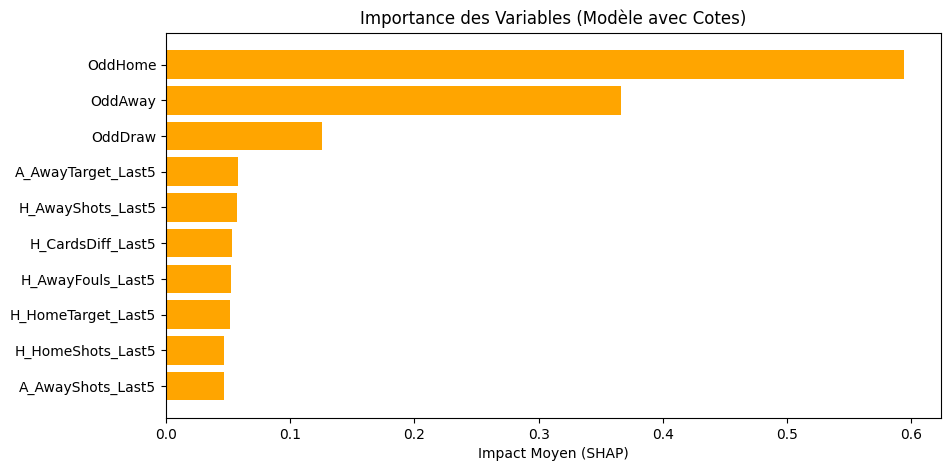

In [16]:
# V1 : XGBOOST BENCHMARK (AVEC COTES)
print("V1 : XGBOOST AVEC COTES (BENCHMARK)")

# Sélection des Features (Sport + Cotes)
macro_feats = ["EloDiff", "EloAdvantage", "Form3Diff", "Form5Diff", "FormMomentumHome"]
market_feats = ["OddHome", "OddDraw", "OddAway", "ImpProb_Home", "ImpProb_Draw"]
technical_feats = [c for c in df_model.columns if "_Last5" in c]

# On filtre pour ne prendre que ce qui existe
features_full = macro_feats + market_feats + technical_feats
features_full = [f for f in features_full if f in df_model.columns]

print(f"Training sur {len(features_full)} variables (dont Cotes)...")

# Config Modèle
weights = df_model["Target"].map({0: 1.0, 1: 1.1, 2: 1.0}) # Poids léger sur le nul

model_full = xgb.XGBClassifier(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=5,        
    subsample=0.8, 
    colsample_bytree=0.8,
    objective='multi:softprob', 
    num_class=3, 
    n_jobs=-1, 
    random_state=42, 
    verbosity=0
)

# Boucle d'Entraînement et Comparaison
tscv = TimeSeriesSplit(n_splits=5)
dfs_full_list = []
shap_values_full = None
acc_scores_model = []

for fold_id, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    # Split
    X_train = df_model.iloc[train_idx][features_full]
    y_train = df_model.iloc[train_idx]["Target"]
    w_train = weights.iloc[train_idx]
    
    df_test_fold = df_model.iloc[test_idx].copy()
    X_test = df_test_fold[features_full]
    
    # Train
    model_full.fit(X_train, y_train, sample_weight=w_train)
    
    # Predict
    probs = model_full.predict_proba(X_test)
    preds = np.argmax(probs, axis=1)
    
    # Calcul des scores
    acc_model = accuracy_score(df_test_fold["Target"], preds)
    acc_scores_model.append(acc_model)
    
    # Comparaison immédiate avec le marché
    acc_market = market_acc_scores[fold_id] 
    
    print(f"Fold {fold_id+1} | Modèle: {acc_model:.2%} vs Marché: {acc_market:.2%} (Delta: {acc_model - acc_market:+.2%})")
    
    # Stockage
    df_test_fold["Prob_H"] = probs[:, 0]
    df_test_fold["Prob_D"] = probs[:, 1]
    df_test_fold["Prob_A"] = probs[:, 2]
    df_test_fold["Pred"] = preds
    dfs_full_list.append(df_test_fold)
    
    # SHAP (Dernier fold)
    if fold_id == 4:
        explainer = shap.TreeExplainer(model_full)
        shap_values_full = explainer.shap_values(X_test)

df_results_full = pd.concat(dfs_full_list)

# Analyse des Résultats
print(f"Accuracy Globale XGB (V1) : {np.mean(acc_scores_model):.2%}")
print(f"Delta moyen vs Marché     : {np.mean(acc_scores_model) - np.mean(market_acc_scores):+.2%}")

# Preuve SHAP (-> Dominance des Cotes)
if isinstance(shap_values_full, list):
    vals = np.abs(shap_values_full[0]) + np.abs(shap_values_full[1]) + np.abs(shap_values_full[2])
else:
    vals = np.sum(np.abs(shap_values_full), axis=2)

feat_imp = pd.DataFrame({'Feature': features_full, 'Importance': np.mean(vals, axis=0)})
top_features = feat_imp.sort_values("Importance", ascending=False).head(10)

print(top_features.to_string(index=False))

# Graphique Importance
plt.figure(figsize=(10, 5))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1], color='orange')
plt.title("Importance des Variables (Modèle avec Cotes)")
plt.xlabel("Impact Moyen (SHAP)")
plt.show()

In [17]:
# V2 : MODÈLE AVEUGLE VS MARCHÉ
print("V2 : XGBOOST AVEUGLE (SANS COTES)")

# Sélection des Features "Blind" (Uniquement Sportives)
macro_feats = ["EloDiff", "EloAdvantage", "Form3Diff", "Form5Diff", "FormMomentumHome", "FormMomentumAway"]
technical_feats = [c for c in df_model.columns if "_Last5" in c]

features_blind = macro_feats + technical_feats
features_blind = [f for f in features_blind if f in df_model.columns]

print(f"Features utilisées : {len(features_blind)} (Macro + Technique)")

# Configuration du Modèle
# On garde les mêmes poids pour aider légèrement le Nul
weights = df_model["Target"].map({0: 1.0, 1: 1.1, 2: 1.0})

model_blind = xgb.XGBClassifier(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=4,            
    subsample=0.8, 
    colsample_bytree=0.8,
    objective='multi:softprob', 
    num_class=3, 
    n_jobs=-1, 
    random_state=42, 
    verbosity=0
)

# Boucle de Validation et Comparaison
tscv = TimeSeriesSplit(n_splits=5)
dfs_results = []
shap_values_blind = None
last_X_test = None
acc_scores_blind = []
market_acc_scores = []

for fold_id, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    # Split
    X_train = df_model.iloc[train_idx][features_blind]
    y_train = df_model.iloc[train_idx]["Target"]
    w_train = weights.iloc[train_idx]
    
    df_test_fold = df_model.iloc[test_idx].copy()
    X_test = df_test_fold[features_blind]
    
    # Train et Predict (Modèle Aveugle)
    model_blind.fit(X_train, y_train, sample_weight=w_train)
    
    probs = model_blind.predict_proba(X_test)
    preds = np.argmax(probs, axis=1)
    acc_model = accuracy_score(df_test_fold["Target"], preds)
    acc_scores_blind.append(acc_model)
    
    # Benchmark Marché (Sur ce fold) - Comparaison immédiate
    odds_test = df_test_fold[["OddHome", "OddDraw", "OddAway"]]
    preds_market = odds_test.idxmin(axis=1).map({"OddHome": 0, "OddDraw": 1, "OddAway": 2})
    acc_market = accuracy_score(df_test_fold["Target"], preds_market)
    market_acc_scores.append(acc_market)
    
    # Stockage
    df_test_fold["Prob_H"] = probs[:, 0]
    df_test_fold["Prob_D"] = probs[:, 1]
    df_test_fold["Prob_A"] = probs[:, 2]
    df_test_fold["Pred"] = preds
    dfs_results.append(df_test_fold)
    
    # Logs
    d_date = df_test_fold["MatchDate"].max().date()
    print(f"Fold {fold_id+1} ({d_date}) | Modèle: {acc_model:.2%} vs Marché: {acc_market:.2%} (Delta: {acc_model - acc_market:+.2%})")
    
    # SHAP (Dernier fold uniquement)
    if fold_id == 4:
        explainer = shap.TreeExplainer(model_blind)
        shap_values_blind = explainer.shap_values(X_test)
        last_X_test = X_test

df_results = pd.concat(dfs_results)

# 4. Bilan Global
print(f"Accuracy Globale XGB Aveugle : {np.mean(acc_scores_blind):.2%}")
print(f"Accuracy Globale Marché      : {np.mean(market_acc_scores):.2%}")
print(f"Écart de Performance         : {np.mean(acc_scores_blind) - np.mean(market_acc_scores):+.2%}")

V2 : XGBOOST AVEUGLE (SANS COTES)
Features utilisées : 36 (Macro + Technique)
Fold 1 (2013-01-26) | Modèle: 49.88% vs Marché: 52.44% (Delta: -2.56%)
Fold 2 (2016-02-03) | Modèle: 51.95% vs Marché: 53.24% (Delta: -1.29%)
Fold 3 (2019-02-04) | Modèle: 53.16% vs Marché: 55.16% (Delta: -2.00%)
Fold 4 (2022-02-13) | Modèle: 51.82% vs Marché: 53.16% (Delta: -1.34%)
Fold 5 (2025-02-26) | Modèle: 52.49% vs Marché: 54.13% (Delta: -1.64%)
Accuracy Globale XGB Aveugle : 51.86%
Accuracy Globale Marché      : 53.63%
Écart de Performance         : -1.77%


PERFORMANCE GLOBALE (XGB AVEUGLE)
Accuracy      : 51.86%
Log Loss      : 0.9929
Brier Score   : 0.2183 (Home Win)
              precision    recall  f1-score   support

        Home       0.54      0.81      0.65     12063
        Draw       0.30      0.06      0.10      6795
        Away       0.51      0.46      0.49      7927

    accuracy                           0.52     26785
   macro avg       0.45      0.45      0.41     26785
weighted avg       0.47      0.52      0.46     26785



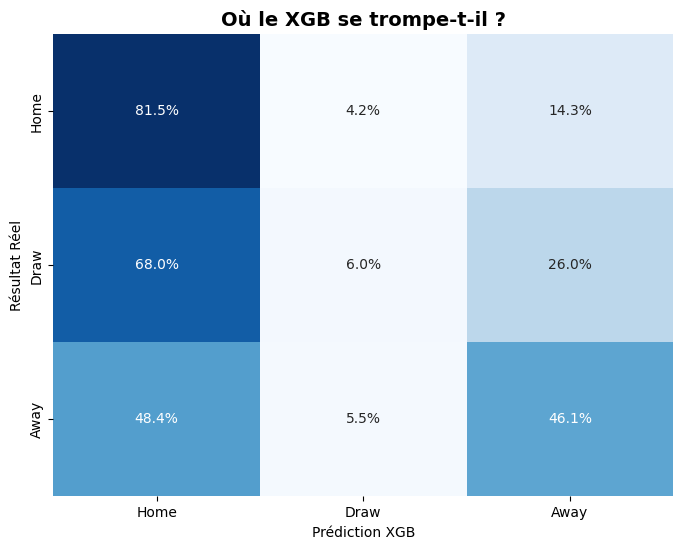

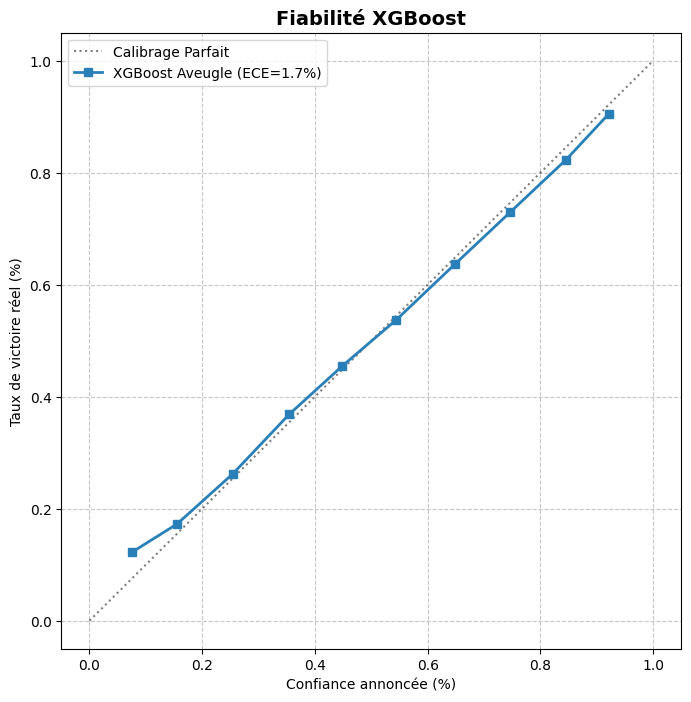

In [18]:
# TABLEAU DE BORD MÉTRIQUES (V2 AVEUGLE)
print("PERFORMANCE GLOBALE (XGB AVEUGLE)")

# Métriques
acc_global = accuracy_score(df_results["Target"], df_results["Pred"])
ll_global = log_loss(df_results["Target"], df_results[["Prob_H", "Prob_D", "Prob_A"]])
y_true_home = (df_results["Target"] == 0).astype(int)
brier = brier_score_loss(y_true_home, df_results["Prob_H"])

print(f"Accuracy      : {acc_global:.2%}")
print(f"Log Loss      : {ll_global:.4f}")
print(f"Brier Score   : {brier:.4f} (Home Win)")
print(classification_report(df_results["Target"], df_results["Pred"], target_names=["Home", "Draw", "Away"]))

# MATRICE DE CONFUSION
plt.figure(figsize=(8, 6))
cm_norm = confusion_matrix(df_results["Target"], df_results["Pred"], normalize='true')

sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues", cbar=False, 
            xticklabels=["Home", "Draw", "Away"],
            yticklabels=["Home", "Draw", "Away"])

plt.title("Où le XGB se trompe-t-il ?", fontsize=14, fontweight='bold')
plt.ylabel("Résultat Réel")
plt.xlabel("Prédiction XGB")
plt.show()

# COURBE DE CALIBRATION 
prob_true, prob_pred = calibration_curve(y_true_home, df_results["Prob_H"], n_bins=10, strategy='uniform')
ece = np.mean(np.abs(prob_pred - prob_true))

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], "k:", label="Calibrage Parfait", alpha=0.5)
plt.plot(prob_pred, prob_true, "s-", color="#2980b9", label=f"XGBoost Aveugle (ECE={ece:.1%})", linewidth=2)

plt.xlabel("Confiance annoncée (%)")
plt.ylabel("Taux de victoire réel (%)")
plt.title("Fiabilité XGBoost", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

DÉCRYPTAGE DU PREMIER ARBRE XGBOOST
Voici comment le modèle prend ses premières décisions (10 premiers nœuds de l'arbre 0) :
 Node                    Feature     Split  Yes   No       Gain
    0               EloAdvantage  0.006432  0-1  0-2 821.181396
    1               EloAdvantage -0.029507  0-3  0-4 191.361801
    2               EloAdvantage  0.046400  0-5  0-6 170.261353
    3               EloAdvantage -0.059649  0-7  0-8  38.685165
    4               EloAdvantage -0.014323  0-9 0-10  20.843483
    5               EloAdvantage  0.025106 0-11 0-12  26.609985
    6               EloAdvantage  0.072938 0-13 0-14  21.672424
    7        H_HomeCorners_Last5  7.800000 0-15 0-16   8.501144
    8 A_GameDominanceIndex_Last5  3.100000 0-17 0-18   8.282700
    9          A_HomeShots_Last5 12.200000 0-19 0-20  12.952997
GÉNÉRATION DE LA LEARNING CURVE


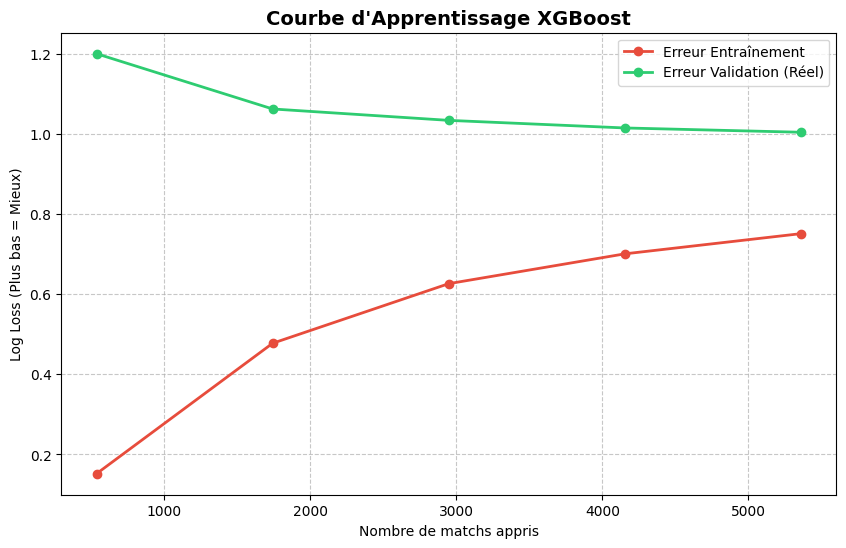

In [19]:
# VISUALISATION DES RÈGLES DE L'ARBRE (Version Texte/Tableau)
print("DÉCRYPTAGE DU PREMIER ARBRE XGBOOST")

# On récupère les données brutes des arbres
df_trees = model_blind.get_booster().trees_to_dataframe()

# On filtre uniquement le tout premier arbre (Tree 0)
first_tree = df_trees[df_trees["Tree"] == 0].head(10) # Les 10 premiers nœuds

print("Voici comment le modèle prend ses premières décisions (10 premiers nœuds de l'arbre 0) :")
# Explication des colonnes :
# Split : La variable testée
# Gain : L'importance de ce test (plus c'est haut, plus c'est crucial)
# Yes/No : Vers quel nœud on va ensuite
print(first_tree[["Node", "Feature", "Split", "Yes", "No", "Gain"]].to_string(index=False))


# DIAGNOSTIC : COURBE D'APPRENTISSAGE (LEARNING CURVE) 
from sklearn.model_selection import learning_curve

print("GÉNÉRATION DE LA LEARNING CURVE")

def plot_learning_curve_custom(estimator, X, y, title):
    # TimeSeriesSplit pour respecter la chronologie
    cv = TimeSeriesSplit(n_splits=5)
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, 
        cv=cv, 
        n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), # 5 étapes (10%, 32%, 55%, 77%, 100%)
        scoring='neg_log_loss' 
    )
    
    # Conversion en positif 
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    
    # Zone de style
    plt.plot(train_sizes, train_scores_mean, 'o-', color="#e74c3c", label="Erreur Entraînement", linewidth=2)
    plt.plot(train_sizes, test_scores_mean, 'o-', color="#2ecc71", label="Erreur Validation (Réel)", linewidth=2)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Nombre de matchs appris")
    plt.ylabel("Log Loss (Plus bas = Mieux)")
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Exécution
plot_learning_curve_custom(model_blind, df_model[features_blind], df_model["Target"], "Courbe d'Apprentissage XGBoost")

ANALYSE SHAP (EXPLICABILITÉ)


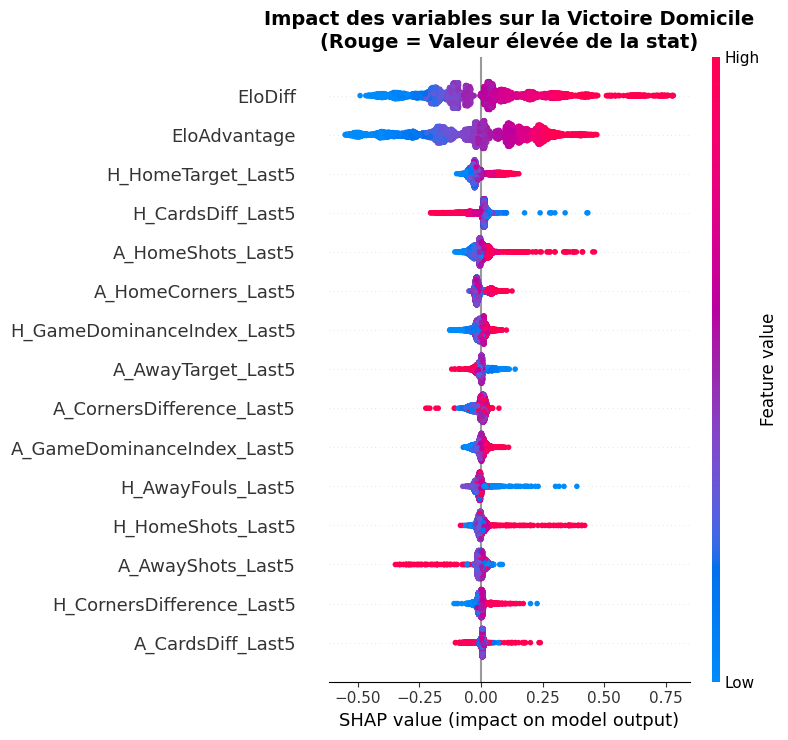

In [20]:
# EXPLICABILITÉ (SHAP) 
print("ANALYSE SHAP (EXPLICABILITÉ)")

# Sélection de la cible (Home Win)
# XGBoost renvoie souvent une liste de matrices [Home, Draw, Away]
if isinstance(shap_values_blind, list):
    vals_target = shap_values_blind[0]
    class_label = "Victoire Domicile"
else:
    # Gestion compatibilité array (N_samples, N_features, N_classes)
    if len(shap_values_blind.shape) == 3:
        vals_target = shap_values_blind[:, :, 0]
    else:
        vals_target = shap_values_blind
    class_label = "Victoire Domicile"

# Graphique Beeswarm
plt.figure(figsize=(12, 8))
plt.title(f"Impact des variables sur la {class_label}\n(Rouge = Valeur élevée de la stat)", fontsize=14, fontweight='bold')

# Utilisation de last_X_test pour garantir la correspondance des données
shap.summary_plot(vals_target, last_X_test, feature_names=features_blind, show=False, max_display=15)

plt.tight_layout()
plt.show()

In [21]:
# ANALYSE FINANCIÈRE et ROI 
print("ANALYSE DE RENTABILITÉ (MODELE AVEUGLE)")

# Calcul de la "Value" détectée par le modèle
# Value = (Probabilité Modèle * Cote Bookmaker) - 1
df_results["Value_H"] = (df_results["Prob_H"] * df_results["OddHome"]) - 1
df_results["Value_D"] = (df_results["Prob_D"] * df_results["OddDraw"]) - 1
df_results["Value_A"] = (df_results["Prob_A"] * df_results["OddAway"]) - 1

# Simulation de Stratégies (Impact de la sélectivité)
thresholds = [0.00, 0.05, 0.10, 0.15, 0.20]
roi_data = []

print("Simulation des paris (Mise fixe = 1 unité) :")
for th in thresholds:
    # On cherche la meilleure Value du match
    max_vals = df_results[["Value_H", "Value_D", "Value_A"]].max(axis=1)
    best_idxs = df_results[["Value_H", "Value_D", "Value_A"]].idxmax(axis=1)
    
    # On filtre : on ne parie que si la Value > Seuil
    mask_bet = max_vals > th
    bets = df_results[mask_bet].copy()
    
    if len(bets) > 0:
        # Calcul du profit
        rewards = []
        for idx, row in bets.iterrows():
            chosen = best_idxs[idx] # ex: "Value_H"
            
            if chosen == "Value_H":
                profit = (row["OddHome"] - 1) if row["Target"] == 0 else -1
            elif chosen == "Value_D":
                profit = (row["OddDraw"] - 1) if row["Target"] == 1 else -1
            else: # Value_A
                profit = (row["OddAway"] - 1) if row["Target"] == 2 else -1
            rewards.append(profit)
            
        total_profit = sum(rewards)
        roi = (total_profit / len(rewards)) * 100
        
        roi_data.append({
            "Seuil Value >": f"{th:.0%}",
            "Nb Paris": len(rewards),
            "ROI": f"{roi:.2f}%",
            "Profit Total": f"{total_profit:.1f}u"
        })
    else:
        roi_data.append({"Seuil Value >": f"{th:.0%}", "Nb Paris": 0, "ROI": "0.00%", "Profit Total": "0"})

# Affichage propre
res_roi = pd.DataFrame(roi_data)
print(res_roi.to_string(index=False))

ANALYSE DE RENTABILITÉ (MODELE AVEUGLE)
Simulation des paris (Mise fixe = 1 unité) :
Seuil Value >  Nb Paris    ROI Profit Total
           0%     24821 -5.79%     -1436.6u
           5%     20700 -6.48%     -1341.1u
          10%     16063 -7.35%     -1180.9u
          15%     12109 -8.20%      -992.8u
          20%      9030 -8.69%      -784.4u


In [22]:
# PROFILAGE DES ERREURS (PAR COTE)
print("OÙ GAGNE-T-ON ? (FOCUS VICTOIRE DOMICILE)")

# On découpe les cotes en tranches (Bins)
bins = [1.0, 1.5, 2.0, 3.0, 5.0, 10.0]
labels = ["Ultra Favori (1.0-1.5)", "Favori (1.5-2.0)", "Outsider (2.0-3.0)", "Gros Outsider (3.0-5.0)", "Longshot (5.0+)"]

df_results["Cote_Bin"] = pd.cut(df_results["OddHome"], bins=bins, labels=labels)

# On analyse uniquement les paris "Home Win" pris avec une Value > 5%
mask_home_bet = df_results["Value_H"] > 0.05
df_bets_home = df_results[mask_home_bet].copy()

if len(df_bets_home) > 0:
    # Agrégation par tranche
    profiling = df_bets_home.groupby("Cote_Bin", observed=False).apply(
        lambda x: pd.Series({
            "Nb Paris": len(x),
            "Win Rate Réel": (x["Target"] == 0).mean(),
            "Cote Moyenne": x["OddHome"].mean(),
            "Profit": (x[x["Target"]==0]["OddHome"] - 1).sum() - len(x[x["Target"]!=0])
        })
    )
    
    profiling["ROI"] = (profiling["Profit"] / profiling["Nb Paris"]) * 100
    
    print(profiling[["Nb Paris", "Win Rate Réel", "Cote Moyenne", "Profit", "ROI"]])
else:
    print("Pas assez de paris Home pour profiler")

OÙ GAGNE-T-ON ? (FOCUS VICTOIRE DOMICILE)
                         Nb Paris  Win Rate Réel  Cote Moyenne  Profit  \
Cote_Bin                                                                 
Ultra Favori (1.0-1.5)      617.0       0.735818      1.356353   -7.12   
Favori (1.5-2.0)           1192.0       0.555369      1.780411  -19.70   
Outsider (2.0-3.0)         2766.0       0.388648      2.474031 -144.36   
Gros Outsider (3.0-5.0)    1805.0       0.244875      3.791025 -161.52   
Longshot (5.0+)             903.0       0.142857      6.869258  -43.28   

                              ROI  
Cote_Bin                           
Ultra Favori (1.0-1.5)  -1.153971  
Favori (1.5-2.0)        -1.652685  
Outsider (2.0-3.0)      -5.219089  
Gros Outsider (3.0-5.0) -8.948476  
Longshot (5.0+)         -4.792913  


C:\Users\Alban\AppData\Local\Temp\ipykernel_23388\1658990001.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profiling = df_bets_home.groupby("Cote_Bin", observed=False).apply(
